# Software-based Traffic Characterization and Statistical Analysis

This notebook assumes the previous execution of the `scripts/prepare_pcap.py` script to generate a CSV from the raw PCAP file. This script will generate a CSV from the input file and perform flow tracking. On a AMD Ryzen 5700U, the script takes ~15min. It is possible to truncate the result by taking a limited amount of packets:

```sh
python scritps/prepare_pcap.py -c 10000 <path-to-pcap>
```

## Introduction
The notebook is structured as follows:

- Packet level analysis:
  + Packet size: fit with bimodal distribution
- Flow level analysis:
  + Flow duration: understand flow duration analysis
 
If **NOT** stated otherwise, all discussions in this notebook are performed on the full dataset. To change the input dataset, just change `fname` variable and re-run all the cells.

In [37]:
import pandas as pd
    
fname = "dataset/201302011400-full.csv"

df = pd.read_csv(fname)

df.head()

,Unnamed: 0,frame.number,frame.time_relative,frame.time_delta,frame.len,ip.src,ip.dst,ip.proto,port.src,port.dst,flow_id
0,0,1,0.000000,NaN,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
1,1,2,0.000003,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
2,2,3,0.000006,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
3,3,4,0.000009,0.000003,94,167.180.134.255,32.218.92.255,1.0,0,0,1
4,4,5,0.000012,0.000003,66,55.146.64.212,211.83.168.117,6.0,49191,3389,2


## Packet size analysis

First, we extract the packet_size from the `frame.len` field of the initial dataset.

Looking at the distribution plotted, it could be fit with the **bimodal** distribution. This can be explained as follows:

- **left peak**: small size packet usually used control traffic (handshake, acks)
- **right peak**: `~1500` bytes packets. Most OS tend to use all availble MTU for frames

The bimodal distribution is the sum of 2 gaussian. We need to estimate $\mu_1, \sigma_1, A_1$ and $\mu_2, \sigma_2, A_2$. This can be done by looking at data we have and using `curve_fit` from the `scipy.optimize` module. To speed up, we can tell the optimizer an initial guess. We know the left peak and right peak *x* position, so we can use them.

### Amplitude estimation
To get the Gaussian $A_1, A_2$, I simply partitioned the initial histogram and looked for the max values in the left zone and right zone. This is performed by looking at data and understanding the distribution initially.

## Goodness of fit
To evaluate the goodness of fit, I calculate the $R^2$ and $RMSE$ using the functions provided below.

\begin{equation}
    R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
\end{equation}

$\overline{y}$ is the mean of the initial dataset. $y_i$ is a point of the initial dataset. $f_{i}$ is a point of the fitted distribution. 

$SS_{res}$ is the sum of square of residual. It indicates how much data fitted in the model differs from the mean value of original data (we take always the sum of squares to remove negative values).
\begin{equation}
    SS_{res} = \sum_{i=1}^n (y_i - f_i)^2
\end{equation}

$SS_{tot}$ is the total sum of squares. It is obtained with the difference between $y_i$ and $\overline{y}$
\begin{equation}
    SST = \sum_{i=1}^n (y_i - \overline{y})^2
\end{equation}

$RMSE$ is the mean distance between predicted data and original data squared:

\begin{equation}
       RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - f_i)^2}
\end{equation}

$0 \leq R^2 \geq 1$. A high $R^2$ tells we have a good fit. On the other hand, a low $RMSE$ tells we have a good fit. $RMSE$ is an easy to calculate factor, but it is sensitive when dealing outliers.

## Results
In this case, $R^2 > 0.9$ so the the `curve_fit` parameter is a good approximation of the initial dataset.

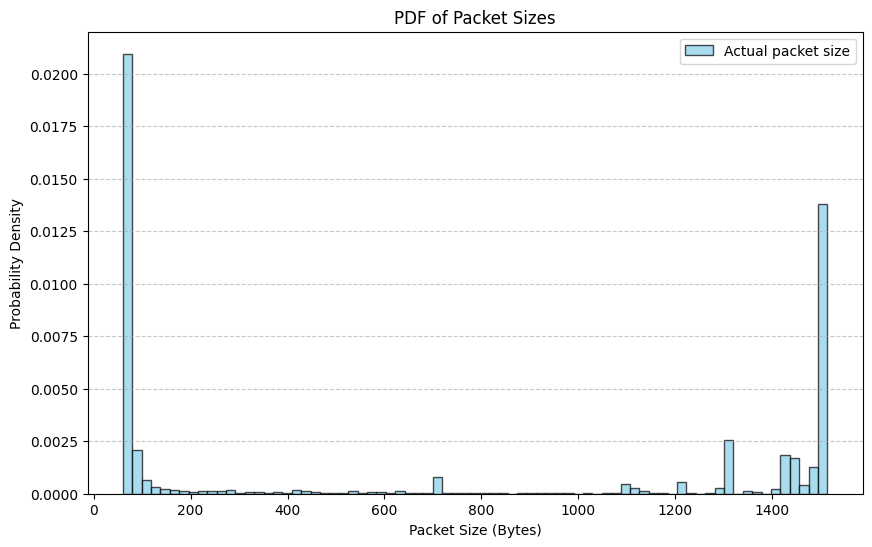

0    1514
1    1514
2    1514
3      94
4      66
Name: frame.len, dtype: int64
Estimated params: [6.94216333e+01 9.13334079e+00 2.09473865e-02 1.50454692e+03
 8.96936209e+00 1.38084146e-02]
R-squared: 0.9754275686185544
RMSE: 0.00044886116288780876


<Figure size 640x480 with 0 Axes>

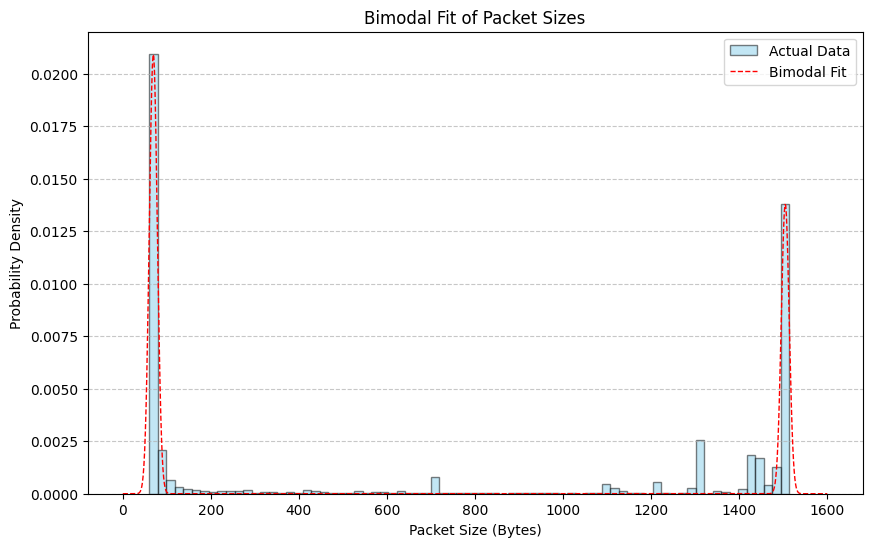

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def rsquared_rmse(predicted_data: np.ndarray, observed_data: np.ndarray) -> float:
    residuals = observed_data - predicted_data
    
    sse = np.sum(residuals ** 2)
    
    sst = np.sum((observed_data - np.mean(observed_data)) ** 2)

    r_squared = 1 - (sse / sst) 
    rmse = np.sqrt(np.mean(residuals**2))
    
    return r_squared, rmse 

# Create the bimodal from the sum of 2 gaussian
def gauss(x,mu,sigma,A):
    return A * np.exp(-(x-mu)**2/2 /sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

bins = 75

packet_sizes = df["frame.len"].dropna()

pdf = plt.figure(figsize=(10, 6))

plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7, label="Actual packet size")
plt.title('PDF of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(packet_sizes.head())
# Save the single pdf for reference.
plt.savefig("figures/pdf-packet_size.pdf")
plt.close(pdf)

# Create a histogram to get the (x, y) coordinates for fitting
counts, bin_edges = np.histogram(packet_sizes, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Search for Amplitude parameter of the 2 gaussian. LLM helped here
left_zone = bin_centers < 500
peak1_center = bin_centers[left_zone][np.argmax(counts[left_zone])]
peak1_height = np.max(counts[left_zone])

right_zone = bin_centers > 1000
peak2_center = bin_centers[right_zone][np.argmax(counts[right_zone])]
peak2_height = np.max(counts[right_zone])

# Initial guess: needed because curve_fit will give "Parameters not found error"
initial_guess = [peak1_center, 10, peak1_height, peak2_center, 10, peak2_height]

# Specify bound to avoid useless search, constrain to both peaks
lower_bounds = [0,   1,   0,                  1000, 1,   0]          
upper_bounds = [500, 200, peak1_height, 1600, 200, peak2_height] 

# Find optimal parameters
params, cov = curve_fit(
    bimodal, 
    bin_centers, 
    counts, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds),
    maxfev=10000
)

plt.figure(figsize=(10,6))
# Plot origial data
plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.5, label="Actual Data")

# Plot the bimodal-distribution
x_range = np.linspace(0, 1600, 1000)
plt.plot(x_range, bimodal(x_range, *params), color='red', linestyle="--", lw=1, label='Bimodal Fit')

plt.title('Bimodal Fit of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("Estimated params:", params)
plt.savefig("figures/bimodalfit-packet-size.pdf")

# Goodness of fit evaluation
y_predicted = bimodal(bin_centers, *params)
y_actual = counts

r_squared, rmse = rsquared_rmse(y_predicted, y_actual)
print("R-squared:", r_squared)
print("RMSE:", rmse)

# Flow analysis
In this section, I perform an analysis at flow level. First, I focus the flow duration.

## Feature extraction
Leveraging, the results from `scripts/prepare_pcap.py`, we can simply aggregate metrics per flow by using the `groupy` method. As in the code, we extract 3 feature and save them in `flow_stats` data frame:

- duration: duration of the flow (from the first to the last packet timestamp registered);
- total bytes: sum of bytes sent over the flow;
- packet count: total number of packets;
- throughput: total bytes sent during the whole communication;
- proto: protocol type;

Using the full input, there are $2889591$ flows 

In [39]:
# Compute duration, total bytes and packet count
print("Number of flows detected:", df["flow_id"].max() + 1)
flow_stats = df.groupby("flow_id").agg(
    duration=("frame.time_relative", lambda x: x.max() - x.min()),
    total_bytes=("frame.len", "sum"),
    packet_count=("frame.number", "count"),
    proto=("ip.proto", "first"),
)

flow_stats['throughput'] = flow_stats['total_bytes'] / flow_stats['duration'].replace(0, 1)

flow_stats.head()

Number of flows detected: 2889592


,duration,total_bytes,packet_count,proto,throughput
flow_id,,,,,
0,132.553151,47034058,31068,6.0,354831.685593
1,720.145928,470,5,1.0,0.652646
2,899.371219,4180134,66245,6.0,4647.840526
3,140.229038,79134,1196,6.0,564.319638
4,0.000000,66,1,6.0,66.000000


## Flow durations analysis
First we plot all the flow durations. To avoid scale problem, I am using $\log_{10}$ scale. At first glance, we notice that the most majority of these connections are very short lived. Looking at the `CDF`, we can understand more than $70%$ of the flows have zero durations.

## Why so many short lived connections?
In my opinion, this is suspect behaviour. I have different hypotheses:
- ICMP noise: most ICMP traffic is for network control;
- UDP protocols: there may be some sort of packet filtering going on;
- TCP broken connection: there can be many TCP partial handshake;

To understand the utilization of the network, I would analyze:

- characterize the protocol of the traffic (percentage TCP, UDP, ICMP etc.);
- compare the duration of TCP flows skipping uncomplete handshake;
- compare the duration of UDP and TCP flows;

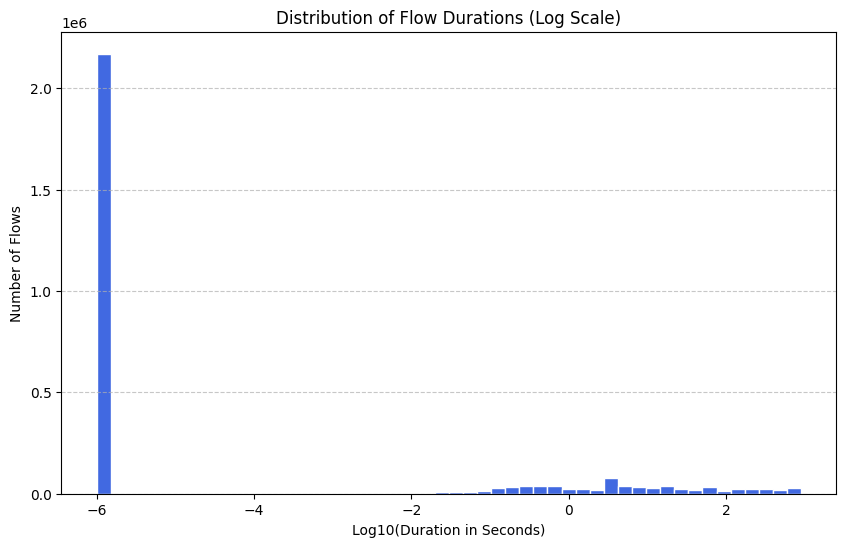

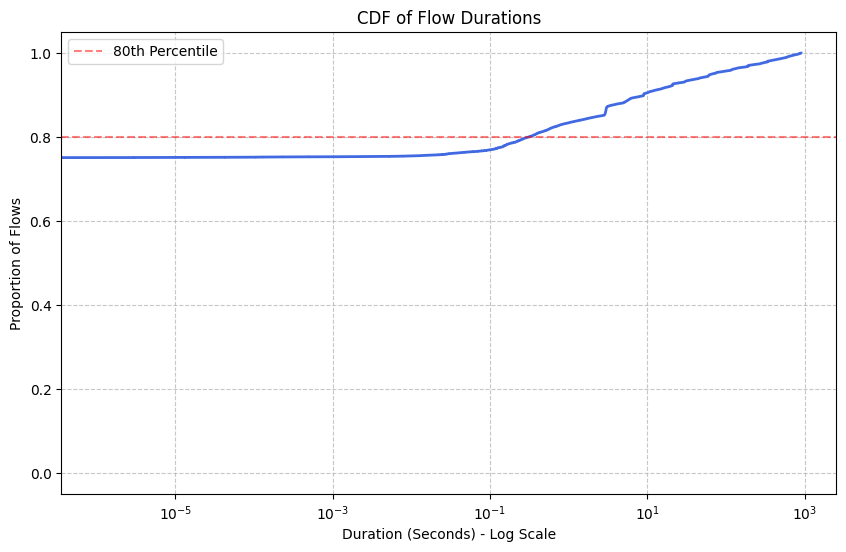

In [84]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Add offset to avoid log10(0)
log_durations = np.log10(flow_stats['duration'] + 1e-6)

# Pure matplotlib histogram
plt.hist(log_durations, bins=50, color='royalblue', edgecolor='white')

plt.title('Distribution of Flow Durations (Log Scale)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/distribution-flow-durations-all.pdf")
plt.show()

plt.figure(figsize=(10, 6))

# 1. Sort the durations
x = np.sort(flow_stats['duration'])

# 2. Calculate the cumulative probability for each point
y = np.arange(1, len(x) + 1) / len(x)

# 3. Plot as a step function
plt.step(x, y, where='post', color='royalblue', linewidth=2)

# Set the x-axis to a logarithmic scale
plt.xscale('log')

plt.title('CDF of Flow Durations')
plt.xlabel('Duration (Seconds) - Log Scale')
plt.ylabel('Proportion of Flows')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80th Percentile')
plt.legend()
plt.savefig("figures/cdf-flow-durations-all.pdf")
plt.show()

## Protocol classification

I performed an analysis for the 3-major protocols. I calculated the percentage of bytes transmitted for each protocol. Looking at plots below:

- ~44% of the traffic is ICMP
- ~31% of the traffic is TCP
- ~19% of the traffic is UDP

Looking at protocol by data, ICMP traffic is less than $1\%$ of the total, while the vast majority of data is exchanged using TCP connections ($~85\%$). While other protocols and UDP use $~13\%$ of the total traffic data.

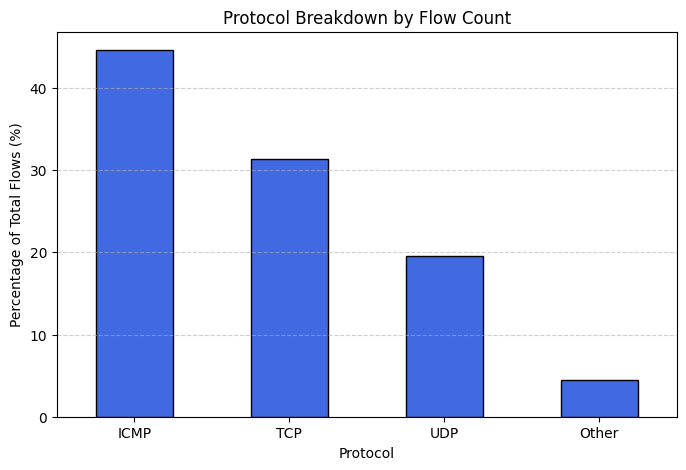

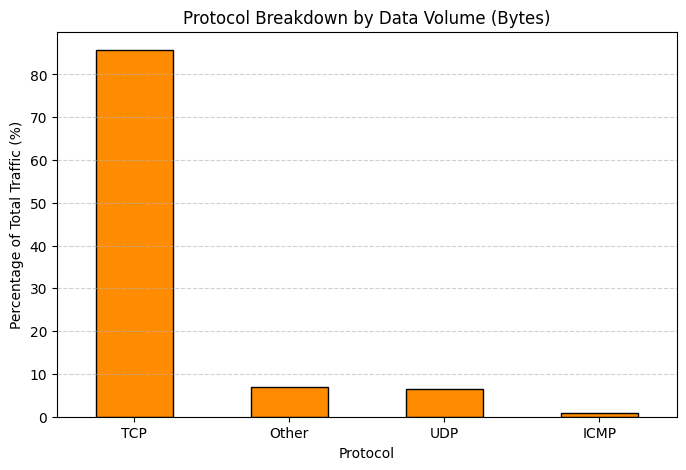

ICMP 44.6007256387753%; ICMP bytes 0.8132273248782872
TCP 31.338611125722938%; TCP bytes 85.69046860129683
UDP 19.541063236609183%; UDP bytes 6.511739004927078
OTHER 4.519599998892578%; UDP bytes 6.984565068897802


In [56]:
import matplotlib.pyplot as plt

proto_map = {6: 'TCP', 17: 'UDP', 1: 'ICMP'}
flow_stats['proto_name'] = flow_stats['proto'].map(proto_map).fillna('Other')

# 2. Calculate percentages by Flow Count
proto_counts = flow_stats['proto_name'].value_counts(normalize=True) * 100

# 3. Calculate percentages by Total Bytes
proto_bytes = flow_stats.groupby('proto_name')['total_bytes'].sum()
proto_bytes_pct = (proto_bytes / proto_bytes.sum()) * 100

# Plot 1: Flow Count
plt.figure(figsize=(8, 5))
proto_counts.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Protocol Breakdown by Flow Count')
plt.ylabel('Percentage of Total Flows (%)')
plt.xlabel('Protocol')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig("figures/proto-byflow.pdf")
plt.show()

# Plot 2: By Byte Count
plt.figure(figsize=(8, 5))
proto_bytes_pct.sort_values(ascending=False).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Protocol Breakdown by Data Volume (Bytes)')
plt.ylabel('Percentage of Total Traffic (%)')
plt.xlabel('Protocol')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig("figures/proto-bybytes.pdf")
plt.show()

print(f"ICMP {proto_counts['ICMP']}%; ICMP bytes {proto_bytes_pct['ICMP']}")
print(f"TCP {proto_counts['TCP']}%; TCP bytes {proto_bytes_pct['TCP']}")
print(f"UDP {proto_counts['UDP']}%; UDP bytes {proto_bytes_pct['UDP']}")
print(f"OTHER {proto_counts['Other']}%; UDP bytes {proto_bytes_pct['Other']}")

## TCP analysis

Given that TCP produces $~85\%$ of data in the network and given that the $~70\%$ of the flows in the network have $~0s$ durations, I analyzed the amount of TCP traffic that does not complete the handhshake. 

As shown in the plots below, $~51\%$ of TCP flows contains less than 4 packets. This means that they do either do not complete handshake or just contain a single segment.

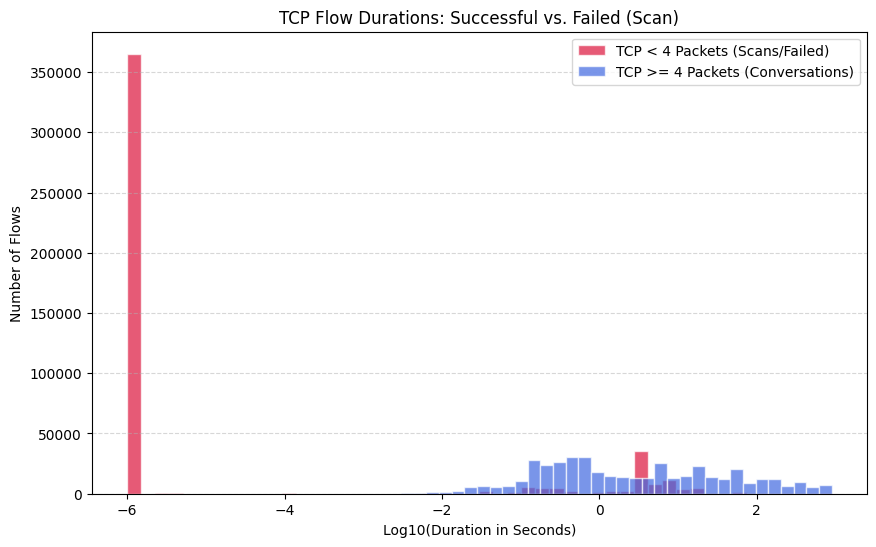

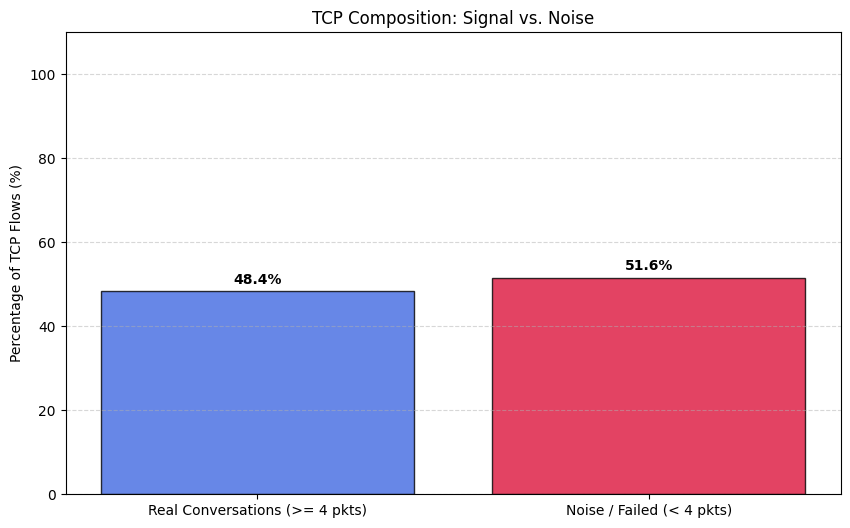

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter TCP traffic
tcp_all = flow_stats[flow_stats['proto'] == 6]
total_tcp_count = len(tcp_all)

# 2. Split into two groups
tcp_real = tcp_all[tcp_all['packet_count'] >= 4]
tcp_noise = tcp_all[tcp_all['packet_count'] < 4]

tcp_real_count = len(tcp_all[tcp_all['packet_count'] >= 4])
tcp_noise_count = len(tcp_all[tcp_all['packet_count'] < 4])

pct_real = (tcp_real_count / total_tcp_count) * 100
pct_noise = (tcp_noise_count / total_tcp_count) * 100

# 3. Calculate log durations
log_real = np.log10(tcp_real['duration'] + 1e-6)
log_noise = np.log10(tcp_noise['duration'] + 1e-6)

# 4. Plot
plt.figure(figsize=(10, 6))

# Plotting the 'Noise' (Short/Failed) in Red
plt.hist(log_noise, bins=50, color='crimson', alpha=0.7, 
         label='TCP < 4 Packets (Scans/Failed)', edgecolor='white')

# Plotting the 'Real' (Successful) in Blue
plt.hist(log_real, bins=50, color='royalblue', alpha=0.7, 
         label='TCP >= 4 Packets (Conversations)', edgecolor='white')

plt.title('TCP Flow Durations: Successful vs. Failed (Scan)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/tcp-durations-broken-vs-ok.pdf")
plt.show()

# 4. Plot
plt.figure(figsize=(10,6))
categories = ['Real Conversations (>= 4 pkts)', 'Noise / Failed (< 4 pkts)']
percentages = [pct_real, pct_noise]
colors = ['royalblue', 'crimson']

bars = plt.bar(categories, percentages, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('TCP Composition: Signal vs. Noise')
plt.ylabel('Percentage of TCP Flows (%)')
plt.ylim(0, 110) # Leave room for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/tcp-perc-broken-vs-ok.pdf")
plt.show()

## UDP

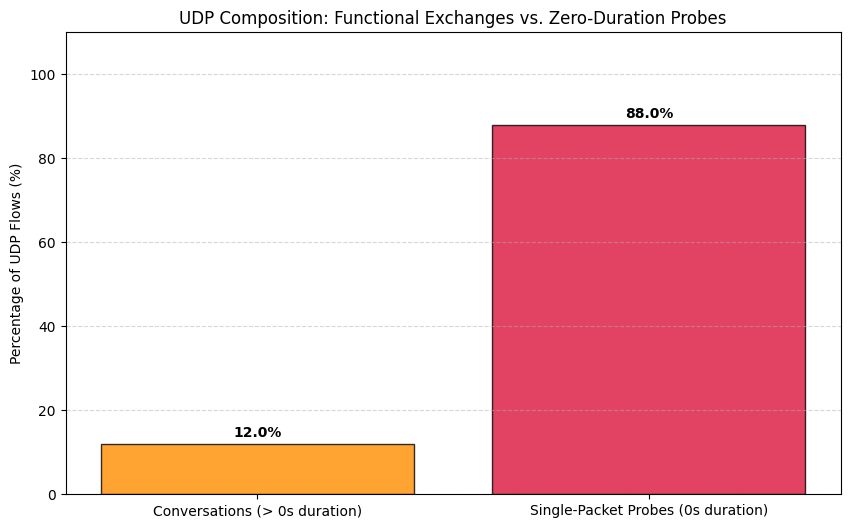

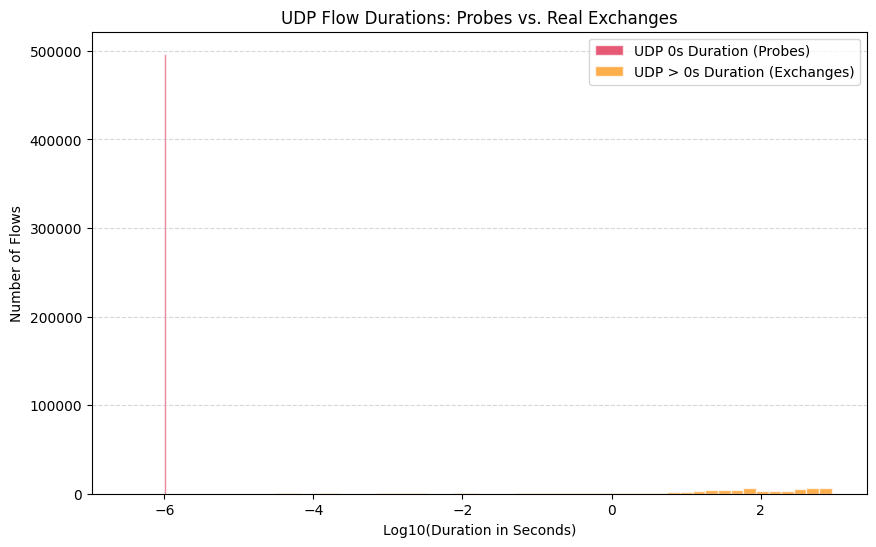

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter UDP traffic
udp_all = flow_stats[flow_stats['proto'] == 17]
total_udp_count = len(udp_all)

# 2. Split into two groups based on duration
# Zero duration = single packet probe; Non-zero = multi-packet exchange
udp_zero = udp_all[udp_all['duration'] == 0]
udp_real = udp_all[udp_all['duration'] > 0]

udp_zero_count = len(udp_zero)
udp_real_count = len(udp_real)

# 3. Calculate Percentages
pct_zero = (udp_zero_count / total_udp_count) * 100
pct_real = (udp_real_count / total_udp_count) * 100

# 4. Bar Plot: UDP Composition
plt.figure(figsize=(10, 6))
categories = ['Conversations (> 0s duration)', 'Single-Packet Probes (0s duration)']
percentages = [pct_real, pct_zero]
colors = ['darkorange', 'crimson']

bars = plt.bar(categories, percentages, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('UDP Composition: Functional Exchanges vs. Zero-Duration Probes')
plt.ylabel('Percentage of UDP Flows (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/udp-perc-zero-vs-real.pdf")
plt.show()

# 5. Histogram for visual confirmation
plt.figure(figsize=(10, 6))

log_real_udp = np.log10(udp_real['duration'] + 1e-6)
log_zero_udp = np.log10(udp_zero['duration'] + 1e-6) # This will all be -6

plt.hist(log_zero_udp, bins=50, color='crimson', alpha=0.7, 
         label='UDP 0s Duration (Probes)', edgecolor='white')
plt.hist(log_real_udp, bins=50, color='darkorange', alpha=0.7, 
         label='UDP > 0s Duration (Exchanges)', edgecolor='white')

plt.title('UDP Flow Durations: Probes vs. Real Exchanges')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/udp-durations-zero-vs-real.pdf")
plt.show()

# Real network profile

Removing ICMP traffic and invalid TCP connection, we can see that there are few "long-lived" TCP connections. The following cell shows the duration distribution plot.

The first plot is **TCP only**: here we can see "normal workload" of the network.
In the second, I added the UDP protocol. Most of the UDP flows have $0$ seconds duration.

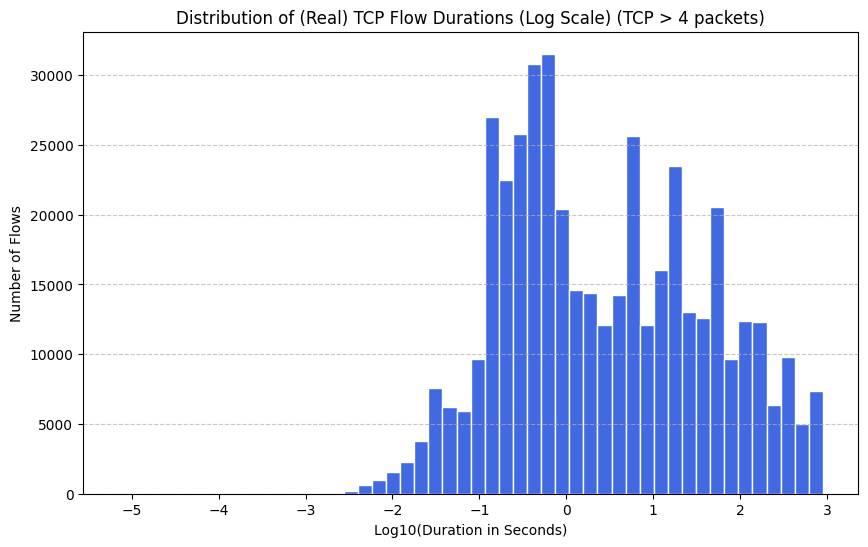

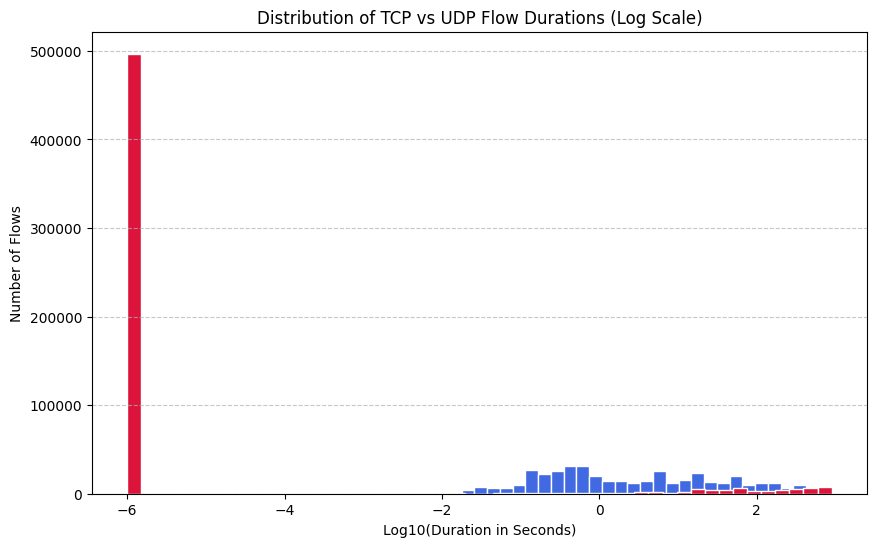

In [101]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Select valid TCP connections
real_tcp = flow_stats[(flow_stats['packet_count'] >= 4) & (flow_stats["proto"] == 6)]

# Add offset to avoid log10(0)
real_tcp_log_durations = np.log10(real_tcp["duration"])

# Pure matplotlib histogram
plt.hist(real_tcp_log_durations, bins=50, color='royalblue', edgecolor='white')

plt.title('Distribution of (Real) TCP Flow Durations (Log Scale) (TCP > 4 packets)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/distribution-flow-durations-tcpreal.pdf")
plt.show()

plt.figure(figsize=(10, 6))

# Select valid TCP connections
real_tcp = flow_stats[(flow_stats['packet_count'] >= 4) & (flow_stats["proto"] == 6)]

# Add offset to avoid log10(0)
real_udp_log_durations = np.log10(real_udp["duration"] + 1e-6)

# Pure matplotlib histogram
plt.hist(real_tcp_log_durations, bins=50, color='royalblue', edgecolor='white')
plt.hist(real_udp_log_durations, bins=50, color='crimson', edgecolor='white')

plt.title('Distribution of TCP vs UDP Flow Durations (Log Scale)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/distribution-flow-durations-tcpudp.pdf")
plt.show()

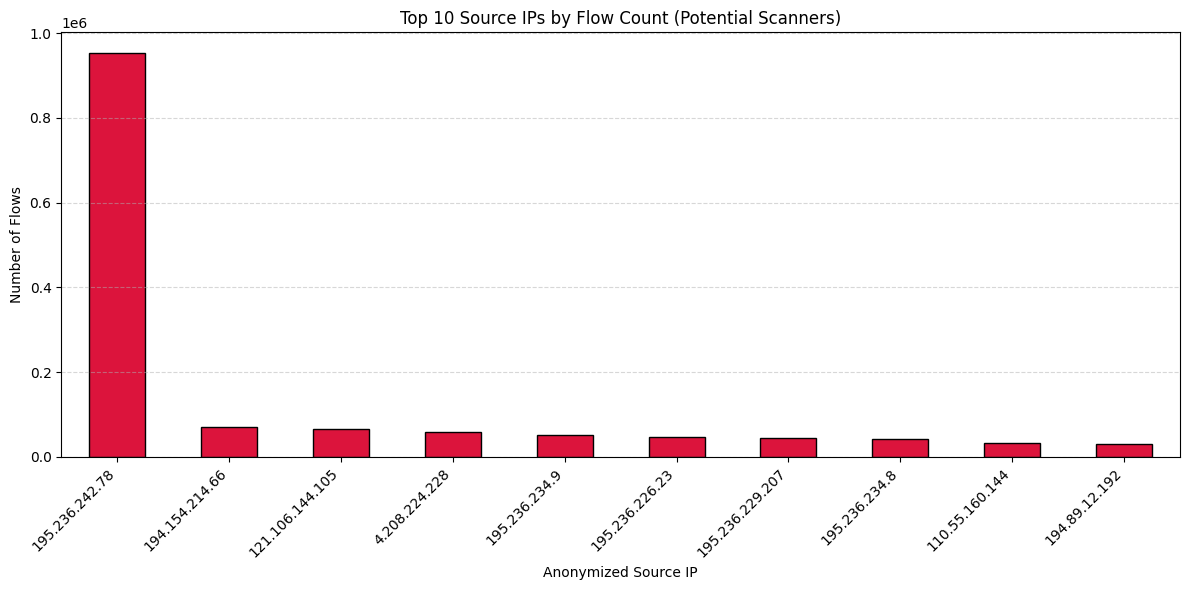

In [104]:
import matplotlib.pyplot as plt

# 1. Group by Source IP (using the anonymized column from your original df)
# Note: replace 'ip.src' with the exact column name in your dataframe
ip_stats = df.groupby('ip.src').agg(
    flow_count=('flow_id', 'nunique'),
    total_bytes=('frame.len', 'sum')
)

# 2. Top 10 by Flow Count
top_flows = ip_stats['flow_count'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_flows.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Top 10 Source IPs by Flow Count (Potential Scanners)')
plt.ylabel('Number of Flows')
plt.xlabel('Anonymized Source IP')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

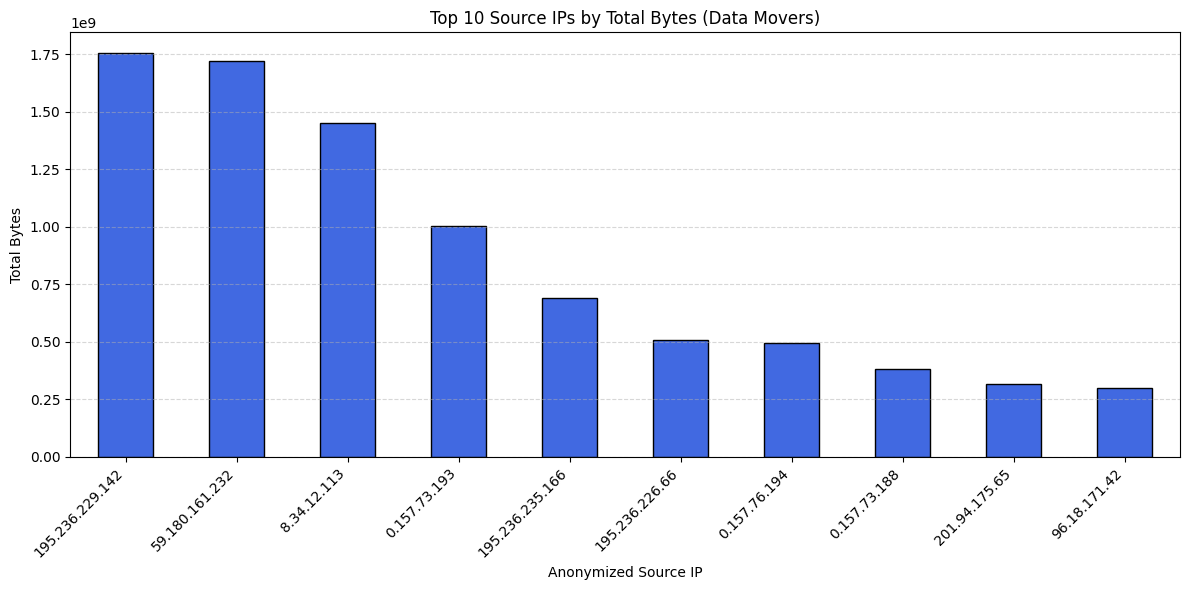

In [105]:
# 3. Top 10 by Byte Count
top_bytes = ip_stats['total_bytes'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_bytes.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Top 10 Source IPs by Total Bytes (Data Movers)')
plt.ylabel('Total Bytes')
plt.xlabel('Anonymized Source IP')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Top 10 by Byte Count
top_bytes = ip_stats['total_bytes'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_bytes.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Top 10 Source IPs by Total Bytes (Data Movers)')
plt.ylabel('Total Bytes')
plt.xlabel('Anonymized Source IP')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Conclusions
The analysis covers a 15-minute snapshot of network traffic containing 2,889,592 flows. Approximately 44% of these flows are ICMP, and 51% of the TCP flows consist of fewer than 4 packets, indicating they did not move meaningful application data. Once this "noise" is filtered, a distinct subset of long-lived connections (10–1000 seconds) emerges, representing the actual functional workload of the network.

## Security considerations
The high volume of ICMP traffic combined with a vast number of incomplete TCP handshakes strongly suggests active network reconnaissance (scanning). The prevalence of zero-second UDP flows further supports this, as they likely represent probes to closed ports. To confirm, Deep Packet Inspection (DPI) or a port-frequency analysis is recommended to identify the specific nature of the UDP and ICMP traffic (e.g., DNS vs. unusual probing).